# Example Electrolyzer Run

This is a simple example that simulates a series of electrolyzer stacks running based on a sinusoidal power signal. The `run_electrolyzer` function accepts either a YAML filepath, or a Dictionary representing a valid model specification. The full structure for an electrolyzer model is defined in the source code, in `modeling_schema.yaml`.

In [2]:
import numpy as np

from electrolyzer import run_electrolyzer_zbt
from electrolyzer.inputs.validation import load_modeling_yaml

In [3]:
turbine_rating = 3.4  # MW

# Create cosine test signal
test_signal_angle = np.linspace(0, 8 * np.pi, 3600 * 8 + 10)
base_value = (turbine_rating / 2) + 0.2
variation_value = turbine_rating - base_value
power_test_signal = (base_value + variation_value * np.cos(test_signal_angle)) * 1e6

### Approach 1: YAML File

In [4]:
fname_input_modeling = "./modeling_options.yaml"

In [5]:
%%time

elec_sys, result_df = run_electrolyzer_zbt(fname_input_modeling, power_test_signal)

CPU times: total: 8 s
Wall time: 8 s


`run_electrolyzer` returns a tuple containing the `Supervisor` instance as well as a time-series `pandas.DataFrame`.

In [6]:
type(elec_sys)

electrolyzer.supervisor.Supervisor

In [7]:
result_df.tail()

,time_h,power_signal,curtailment,kg_rate,stack_1_deg,stack_1_deg_steady,stack_1_deg_fatigue,stack_1_deg_onoff,stack_1_fatigue,stack_1_cycles,...,stack_7_deg_steady,stack_7_deg_fatigue,stack_7_deg_onoff,stack_7_fatigue,stack_7_cycles,stack_7_uptime,stack_7_kg_rate,stack_7_curr_density,stack_7_cell_voltage,stack_7_cell_voltage_no_degrad
28805,8.001389,3.399991e+06,0.0,0.0139,0.00001,0.000009,6.967001e-07,0.0,6.967001e-07,0.0,...,0.000008,7.114274e-07,0.0,7.114274e-07,0.0,28800.0,0.001717,1.764666,2.267544,2.267536
28806,8.001667,3.399995e+06,0.0,0.0139,0.00001,0.000009,6.967001e-07,0.0,6.967001e-07,0.0,...,0.000008,7.114274e-07,0.0,7.114274e-07,0.0,28801.0,0.001717,1.764680,2.267548,2.267540
28807,8.001944,3.399998e+06,0.0,0.0139,0.00001,0.000009,6.967001e-07,0.0,6.967001e-07,0.0,...,0.000008,7.114274e-07,0.0,7.114274e-07,0.0,28802.0,0.001717,1.764690,2.267551,2.267543
28808,8.002222,3.399999e+06,0.0,0.0139,0.00001,0.000009,6.967001e-07,0.0,6.967001e-07,0.0,...,0.000008,7.114274e-07,0.0,7.114274e-07,0.0,28803.0,0.001717,1.764696,2.267553,2.267544
28809,8.002500,3.400000e+06,0.0,0.0139,0.00001,0.000009,6.967001e-07,0.0,6.967001e-07,0.0,...,0.000008,7.114274e-07,0.0,7.114274e-07,0.0,28804.0,0.001717,1.764698,2.267553,2.267545


## Approach 2: Dictionary

This is essentially the same process, but the use of a dictionary allows for easier programmatic runs.

In [ ]:
modeling_input2 = load_modeling_yaml(fname_input_modeling)

# change the number of stacks
modeling_input2["electrolyzer"]["control"]["n_stacks"] = 6

elec_sys2, result_df2 = run_electrolyzer_zbt(modeling_input2, power_test_signal)

In [ ]:
result_df2.tail()

## Example Usage

In [ ]:
result_df["power_signal"].plot(title="Power Signal", xlabel="Time (s)", ylabel="Power (W)")

In [ ]:
result_df["kg_rate"].plot(title="H2 production rate", xlabel="Time (s)", ylabel="H2 rate (kg/s)")

In [ ]:
stack_rates = result_df[[col for col in result_df.columns if "_kg_rate" in col]]

stack_rates.plot(title="H2 production rate by stack", xlabel="Time (s)", ylabel="H2 (kg/s)")

<Axes: title={'center': 'Degradation by stack'}, xlabel='Time (s)', ylabel='Degradation (V)'>

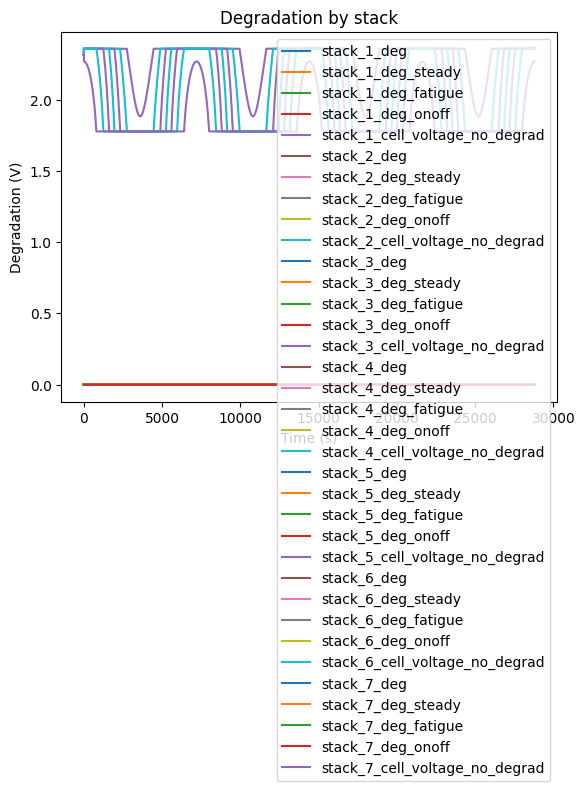

In [9]:
deg = result_df[[col for col in result_df.columns if "deg" in col]]
deg.plot(title="Degradation by stack", xlabel="Time (s)", ylabel="Degradation (V)")

<Axes: title={'center': 'Degradation by stack'}, xlabel='Time (s)', ylabel='Degradation (V)'>

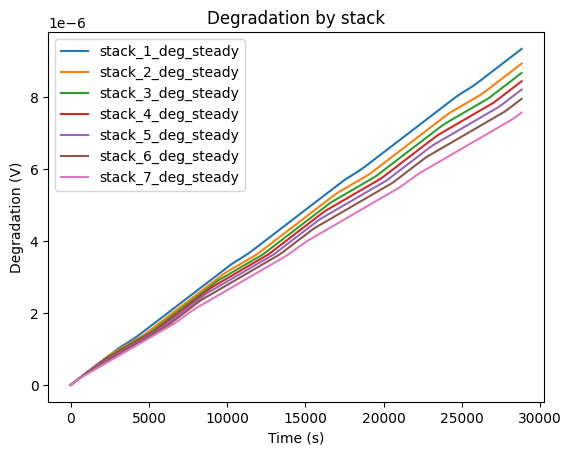

In [10]:
deg = result_df[[col for col in result_df.columns if "deg_steady" in col]]
deg.plot(title="Degradation by stack", xlabel="Time (s)", ylabel="Degradation (V)")

<Axes: title={'center': 'Degradation by stack'}, xlabel='Time (s)', ylabel='Degradation (V)'>

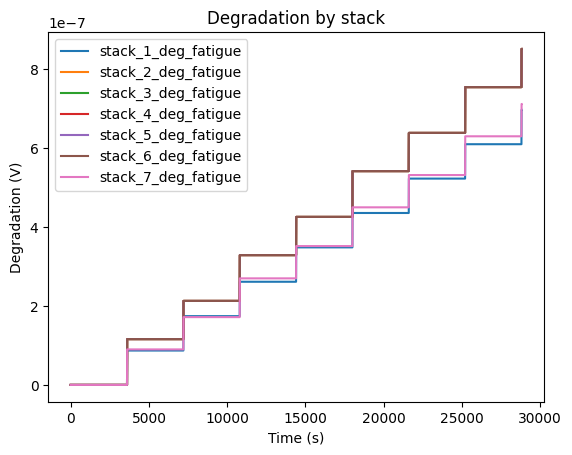

In [11]:
deg = result_df[[col for col in result_df.columns if "deg_fatigue" in col]]
deg.plot(title="Degradation by stack", xlabel="Time (s)", ylabel="Degradation (V)")

In [ ]:
result_df.columns

In [ ]:
# Total kg
result_df["kg_rate"].sum()

In [ ]:
curr_dens = result_df[[col for col in result_df.columns if "curr" in col]]
curr_dens.plot(title="Current Density by stack", xlabel="Time (s)", ylabel="Current Density ($A/cm^2$)")

In [ ]:
max(curr_dens.max().values)